# Breast Cancer Tumor Classification: Logistic Regression & KNN

## Part 1: Logistic Regression Walkthrough
Logistic Regression is a statistical method for analyzing a dataset in which there are one or more independent variables that determine an outcome. The outcome is measured with a dichotomous variable (where there are only two possible outcomes). It is used for binary classification tasks.

In this part, we will implement Logistic Regression to predict whether a patient has a particular disease based on certain diagnostic measurements. We will use a breast cancer dataset available through `sklearn.datasets` .

### Step 1: Import Necessary Libraries

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Step 2: Load & Split the Dataset

In [10]:
# Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data)
y = data.target

print (X.head())
print (y)
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

      0      1       2       3        4        5       6        7       8   \
0  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001  0.14710  0.2419   
1  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869  0.07017  0.1812   
2  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974  0.12790  0.2069   
3  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414  0.10520  0.2597   
4  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980  0.10430  0.1809   

        9   ...     20     21      22      23      24      25      26      27  \
0  0.07871  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.05667  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.05999  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.09744  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.05883  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       28       29  
0  0.4601  0.11890  
1 

**1. test_size**: Determines the percentage of data set aside for testing. A test_size=0.2 means 20% of the data is used to evaluate the model, and 80% is used for training.

**2. random_state**: Sets a specific seed for the random number generator. This ensures the data is split the exact same way every time you run the code, allowing for reproducible results.

### Step 3 (optional): EDA

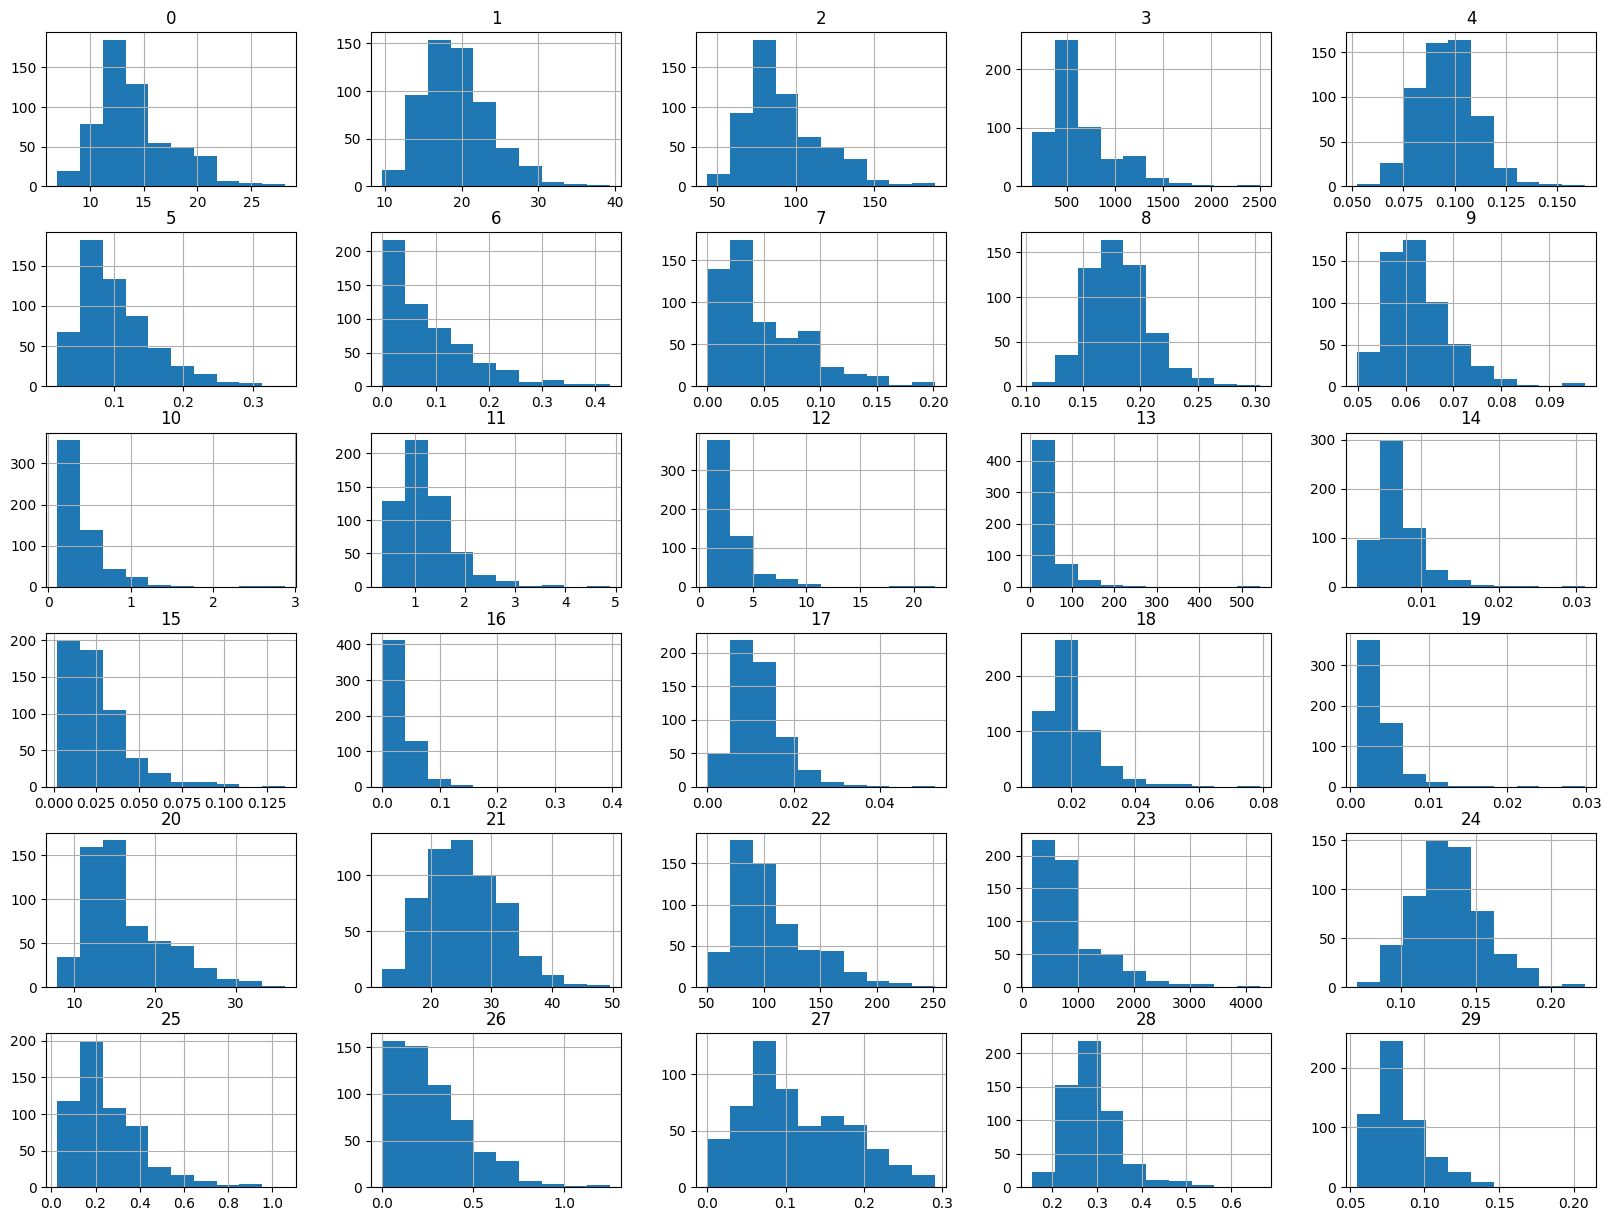

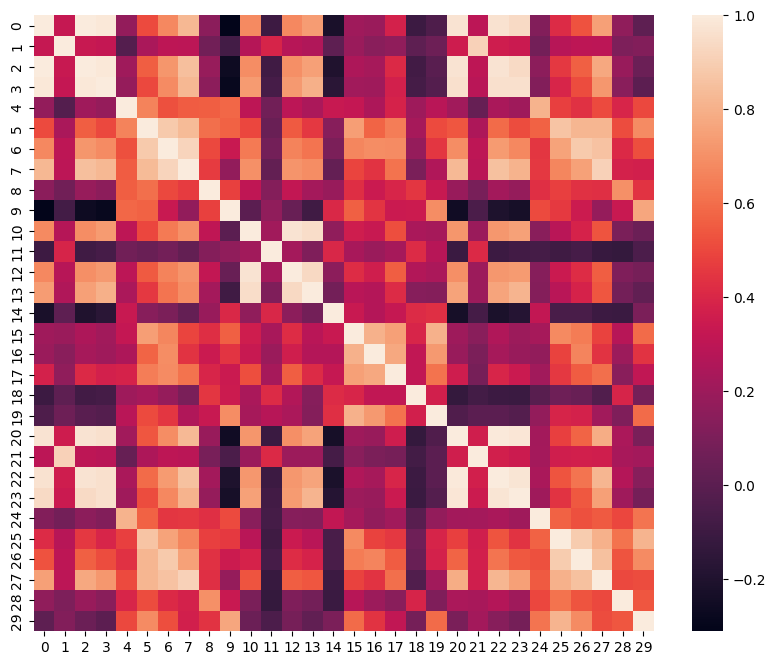

In [11]:
# Here is just an example for EDA.
# EDA: Visualize the data distributions and relationships
# Plotting histograms for each feature
X.hist(bins=10, figsize=(20,15))


# Correlation matrix
corr_matrix = X.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix)
plt.show()

EDA helps identify data quality issues like missing values, outliers, or highly correlated features early on. Fixing these before training directly improves the model's accuracy.

### Step 4: Model Training

In [12]:
# Train a Logistic Regression model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**1.** The maximum number of iterations the optimization algorithm is allowed to run to find the best model weights.

**2.** Yes, LogisticRegression accepts others like penalty (specifies the type of regularization like 'l1' or 'l2' to prevent overfitting) and C (controls the strength of that regularization).

### Step 5: Model Evaluation

In [13]:
# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
print(f'Accuracy: {accuracy_score(y_test, predictions)}')
print(f'ROC AUC Score: {roc_auc_score(y_test, predictions)}')
print(classification_report(y_test, predictions))

Accuracy: 0.956140350877193
ROC AUC Score: 0.9464461185718965
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



ROC is a probability curve plotting the True Positive Rate against the False Positive Rate. AUC measures the entire area underneath the ROC curve; an AUC of 1.0 is a perfect model, while 0.5 means it's just randomly guessing.

## Part 2: Implement a KNN Model

K-Nearest Neighbors (KNN) is an instance-based learning algorithm where the class of a sample is determined by the majority class among its K nearest neighbors.
For this part, use the Iris dataset and create a KNN model to classify Iris plants into three species based on the sizes of their petals and sepals.

### Task 1: Implement the KNN Pipeline

In [14]:
# Load and split dataset
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    pd.DataFrame(iris.data, columns=iris.feature_names), 
    iris.target, test_size=0.2, random_state=42
)

In [15]:
# Initialize, train, and predict
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
preds = knn.predict(X_test)

In [16]:
# Evaluate
print(f'Accuracy: {accuracy_score(y_test, preds):.4f}\n')
print(classification_report(y_test, preds, target_names=iris.target_names))

Accuracy: 1.0000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

